<a href="https://colab.research.google.com/github/avnish22/High-Risk-Patients---Predictions/blob/main/High_Risk_Patients_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 60.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
from sklearn.model_selection import train_test_split

## 1. Import Libraries & Load data

In [3]:
!pip install imbalanced-learn --quiet

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("/content/hospital_readmissions_30k.csv")
print("shape of dateset: ", df.shape)

shape of dateset:  (30000, 12)


In [6]:
df.head(3)

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No


### Code for Blood Pressure

In [7]:
# Split blood_pressure into systolic and diastolic

df[['systolic_bp', 'diastolic_bp']] = df.blood_pressure.str.split('/', expand = True)

# Convert to numeric

df['systolic_bp'] = pd.to_numeric(df['systolic_bp'])
df['diastolic_bp'] = pd.to_numeric(df['diastolic_bp'])

In [8]:
df.drop('blood_pressure', axis = 1, inplace = True)

In [9]:
df.info()
df.describe(include = "object")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   cholesterol            30000 non-null  int64  
 4   bmi                    30000 non-null  float64
 5   diabetes               30000 non-null  object 
 6   hypertension           30000 non-null  object 
 7   medication_count       30000 non-null  int64  
 8   length_of_stay         30000 non-null  int64  
 9   discharge_destination  30000 non-null  object 
 10  readmitted_30_days     30000 non-null  object 
 11  systolic_bp            30000 non-null  int64  
 12  diastolic_bp           30000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 3.0+ MB


,gender,diabetes,hypertension,discharge_destination,readmitted_30_days
count,30000,30000,30000,30000,30000
unique,3,2,2,3,2
top,Male,No,No,Home,No
freq,10097,15051,15022,20877,26326


In [10]:
df.describe()

,patient_id,age,cholesterol,bmi,medication_count,length_of_stay,systolic_bp,diastolic_bp
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,53.884233,225.260400,28.946263,5.012267,5.502900,134.968333,85.025467
std,8660.398374,21.056485,43.585671,6.348204,3.166383,2.867298,14.671463,8.923060
min,1.000000,18.000000,150.000000,18.000000,0.000000,1.000000,110.000000,70.000000
25%,7500.750000,36.000000,188.000000,23.400000,2.000000,3.000000,122.000000,77.000000
50%,15000.500000,54.000000,225.000000,28.900000,5.000000,5.000000,135.000000,85.000000
75%,22500.250000,72.000000,263.000000,34.500000,8.000000,8.000000,148.000000,93.000000
max,30000.000000,90.000000,300.000000,40.000000,10.000000,10.000000,160.000000,100.000000


## 2. Data Understanding & EDA with new BP

In [11]:
# missing value check

print("Missing values:\n", df.isnull().sum().sum())

# Target distribution

print("Readmission distribution:\n", df['readmitted_30_days'].value_counts(normalize=True) * 100)

Missing values:
 0
Readmission distribution:
 readmitted_30_days
No     87.753333
Yes    12.246667
Name: proportion, dtype: float64


In [12]:
# Unique values categorical

categorical_cols = ['gender','diabetes','hypertension','discharge_destination','readmitted_30_days']
for col in categorical_cols:
    print(f"{col} unique values: {df[col].unique()}")

gender unique values: ['Other' 'Female' 'Male']
diabetes unique values: ['Yes' 'No']
hypertension unique values: ['No' 'Yes']
discharge_destination unique values: ['Nursing_Facility' 'Home' 'Rehab']
readmitted_30_days unique values: ['Yes' 'No']


In [13]:
# eda plots

def eda_plots(df, target_col):
    categorical_cols = ['gender', 'diabetes', 'hypertension', 'discharge_destination']
    continuous_cols = ['age', 'cholesterol', 'bmi',	'medication_count',	'length_of_stay', 'systolic_bp', 'diastolic_bp']

    for col in categorical_cols:
        plt.figure(figsize=(6,4))
        sns.countplot(x = col, hue = target_col, data = df)
        plt.title(f"{col} vs {target_col}")
        plt.xticks(rotation=30)
        plt.show()

    for col1 in continuous_cols:
        plt.figure(figsize=(6,4))
        sns.boxplot(x = target_col, y = col1, data = df)
        plt.title(f"{col1} vs {target_col}")
        plt.show()

        # Histogram with KDE
        plt.figure(figsize=(6,4))
        sns.histplot(data=df, x=col1, hue=target_col, kde=True, element="step")
        plt.title(f"Distribution of {col1} split by {target_col}")
        plt.show()

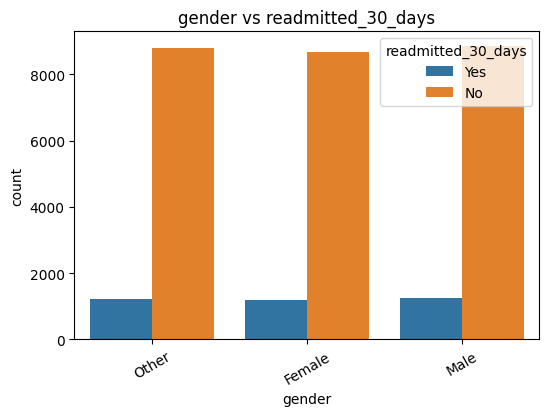

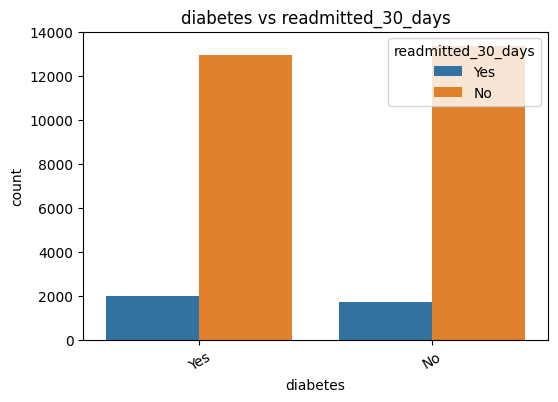

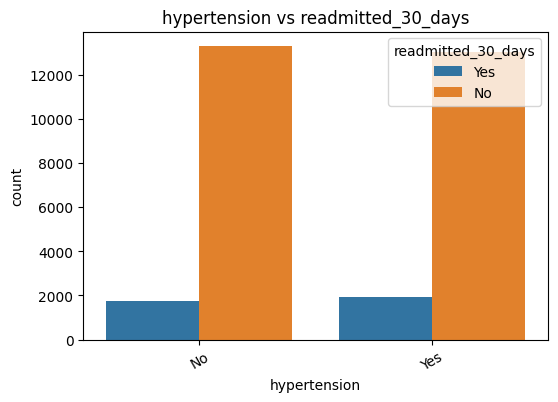

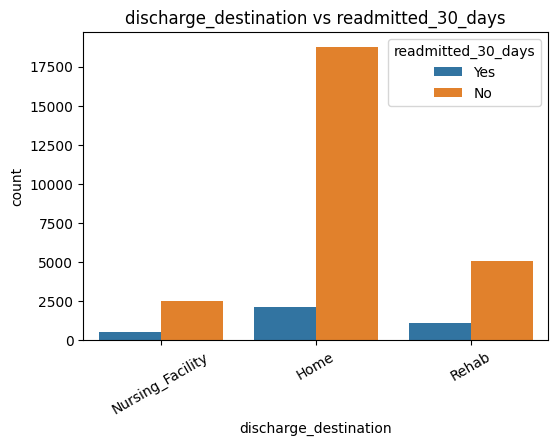

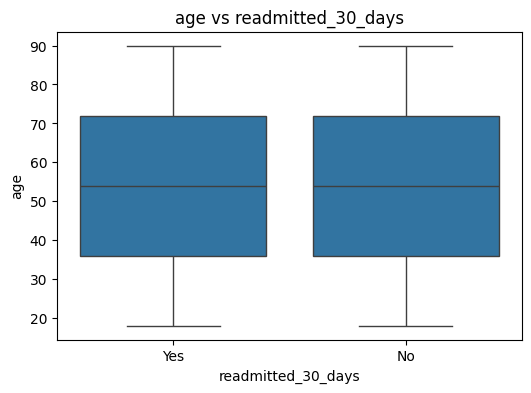

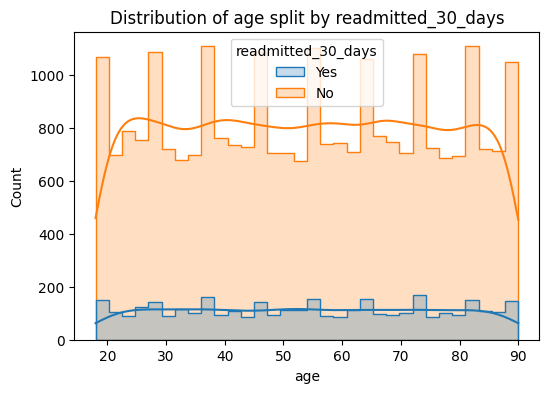

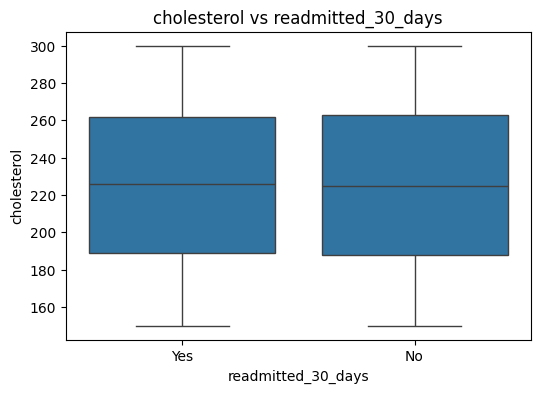

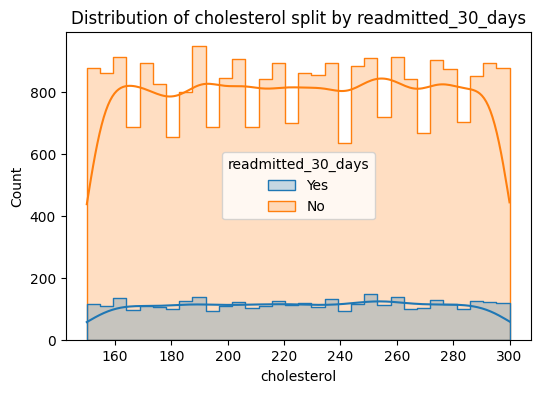

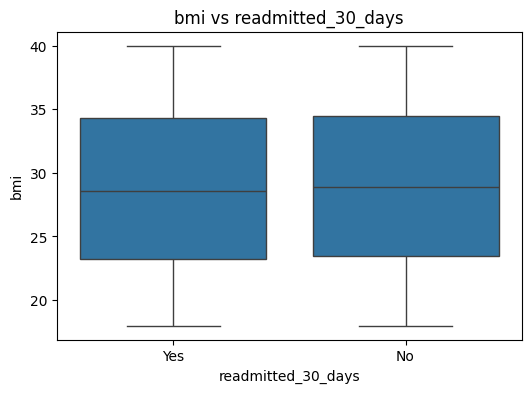

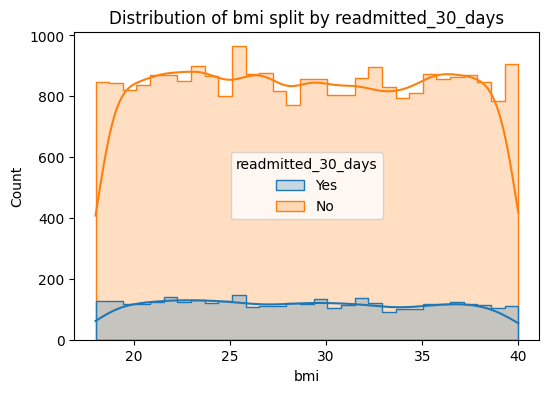

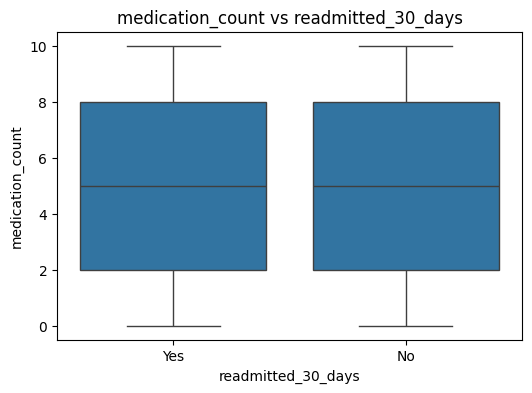

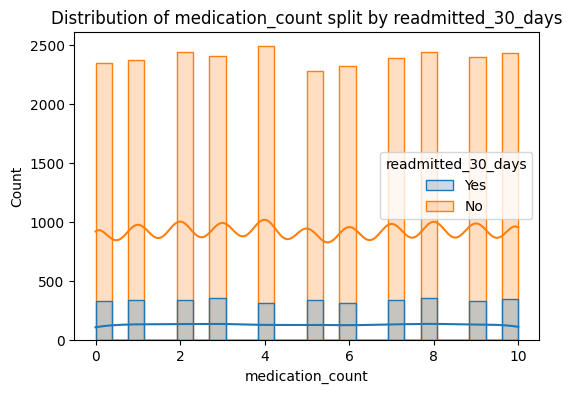

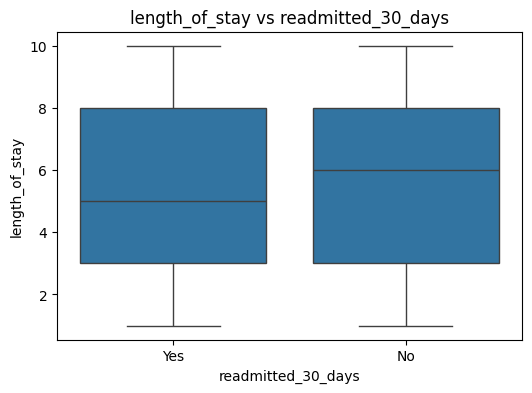

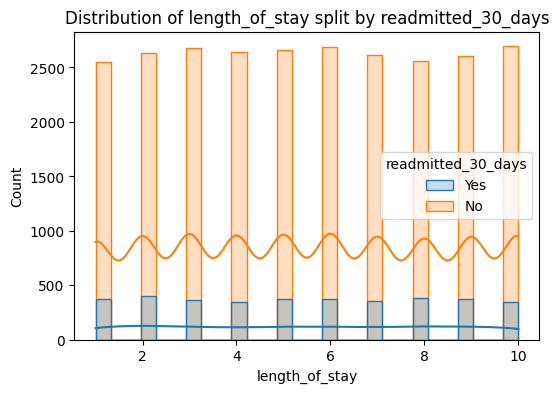

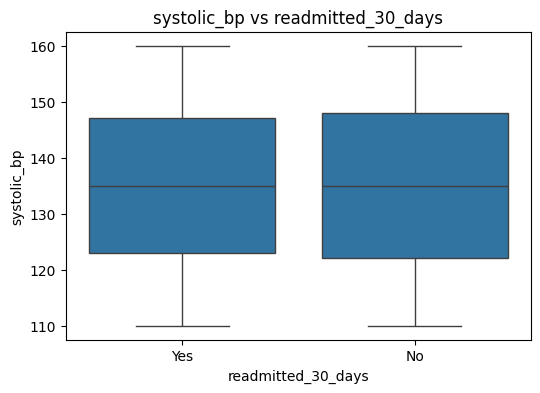

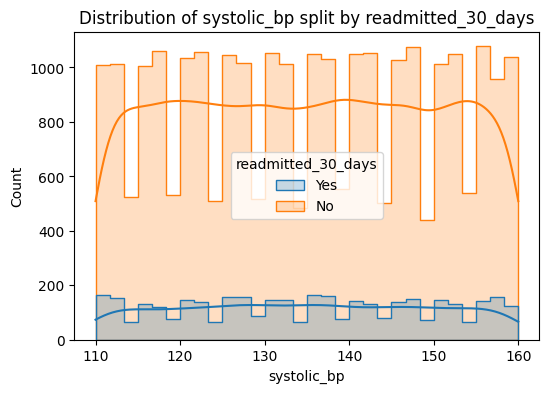

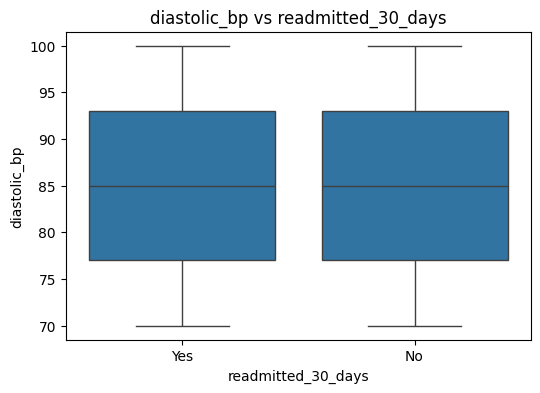

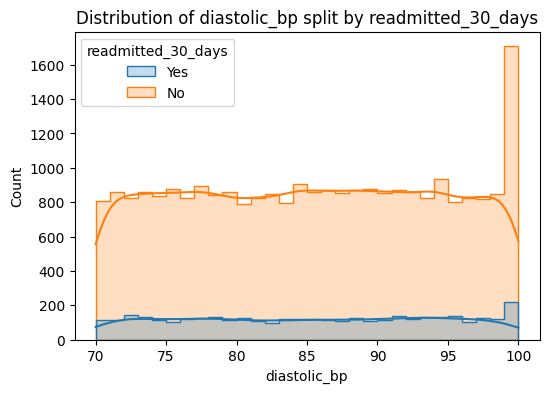

In [14]:
# Call function
eda_plots(df, target_col='readmitted_30_days')

In [15]:
## insights from eda

# Target: Dastset imbalanced (majority " No")
# Age: Elderly (60%) -> higher readmission risk
# Lenght of stay: Longer stay + higher risk, short stay (1-2) = lower risk.
# Discharge Destination: Nursung facility = higher risk vs Home
# Blood Pressure: Extreme BP = higher risk, normal bp = lower risk
# comorbidities: Diabities/ hypertension present = hifgher risk

## 3. Hypothesis Testing

In [16]:
import scipy.stats as stats

In [17]:
def hypothesis_testing(df):
    results = []

    # 1. Categorical variables (Chi-square test)
    cat_vars = ['discharge_destination', 'diabetes', 'hypertension', 'gender']
    for var in cat_vars:
        contingency = pd.crosstab(df[var], df['readmitted_30_days'])
        chi2, p, dof, expected = stats.chi2_contingency(contingency)
        results.append({
            "Variable": var,
            "Test": "Chi-square",
            "Statistic": chi2,
            "p-value": p
        })

    # 2. Numerical variables (T-test or Mann-Whitney if non-normal)
    num_vars = ['systolic_bp', 'diastolic_bp', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']
    for var in num_vars:
        group1 = df[df['readmitted_30_days']=="Yes"][var].dropna()
        group2 = df[df['readmitted_30_days']=="No"][var].dropna()

        # Use t-test
        t_stat, p_val = stats.ttest_ind(group1, group2, nan_policy='omit')
        results.append({
            "Variable": var,
            "Test": "T-test",
            "Statistic": t_stat,
            "p-value": p_val
        })

    return pd.DataFrame(results)

test_results = hypothesis_testing(df)
test_results

,Variable,Test,Statistic,p-value
0,discharge_destination,Chi-square,310.586363,3.606020e-68
1,diabetes,Chi-square,25.994064,3.424688e-07
2,hypertension,Chi-square,15.065243,1.038581e-04
3,gender,Chi-square,0.239176,8.872859e-01
4,systolic_bp,T-test,-0.596179,5.510601e-01
5,diastolic_bp,T-test,-0.348483,7.274797e-01
6,cholesterol,T-test,0.689856,4.902900e-01
7,bmi,T-test,-2.333527,1.962707e-02
8,medication_count,T-test,-0.017063,9.863868e-01
9,length_of_stay,T-test,-1.152623,2.490743e-01


In [18]:
## insights from hypothesis testing

# 1. Discharge destination (p ≈ 0.0) - > vary strong effect. Nursing facility patients much more likely to be readmitted.
# 2. Diabetes (p ≈ 0.0000003) - > Diabetics pateints have significantly higher readmisision risk.
# 3. Hypertension (p ≈ 0.0001) - > Also a significant factor.
# 4. Gender (p ≈ 0.89) - > No impact
# 5. Systolic/Diastolic BP, Cholesterol (p > 0.4) - > no significant effect
# 6. BMI (p ≈ 0.019) - > OVER/unerweight patients slightly more prone to readmission.
# 7. Medication count (p ≈ 0.98) --> No effect
# 8. Length of stay (p ≈ 0.25) --> Not statistically significant in this dataset.

# KEY DRIVERS: Discharge destination, diabetes, hypertension, and BMI.

## 4. Feature Selection + Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [20]:
# drop insignificant features

drop_cols = ['patient_id', 'gender', 'systolic_bp', 'diastolic_bp', 'medication_count', 'cholesterol']
df_model = df.drop(columns = drop_cols)

In [21]:
# encode categorical vars

le = LabelEncoder()
for col in ['diabetes', 'hypertension', 'discharge_destination', 'readmitted_30_days']:
    df_model[col] = le.fit_transform(df_model[col])

In [22]:
# Define X and Y

X = df_model.drop(columns = ['readmitted_30_days'])
y = df_model['readmitted_30_days']

In [23]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (24000, 6)
Testing set shape: (6000, 6)


## 5. Baseline Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, classification_report, confusion_matrix

# train Baseline Logistic Regression

log_reg = LogisticRegression(max_iter = 1000, random_state = 42)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
# Predictions

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

In [30]:
# classification report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8718333333333333
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.5823147441269276
Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5231
           1       0.00      0.00      0.00       769

    accuracy                           0.87      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.76      0.87      0.81      6000

[[5231    0]
 [ 769    0]]


In [27]:
## Insights from this model (classifcation report)

# Model predicts all patients as "Not Readmitted (0)".
# Recall for class 1 = 0.00 -> Model fails to detect high-risk patients.
# High overall accuracy (0.87) is misleading because dataset is imbalanced (majority = 0).
# Need imbalance handling, otherwise business use-case fail (hospital cannot identify risky patients).

# 6. Advanced Model – XGBoost

In [31]:
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [32]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [33]:
# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93      5231
           1       0.24      0.01      0.02       769

    accuracy                           0.87      6000
   macro avg       0.56      0.50      0.47      6000
weighted avg       0.79      0.87      0.81      6000

ROC-AUC Score: 0.5446322675238817
Confusion Matrix:
 [[5209   22]
 [ 762    7]]


In [34]:
# increase in recall for "1" to 10% through xg-boost

## Apply SMOTE with XGBoost

In [37]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [40]:
xgb_smote = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_smote.fit(X_train_res, y_train_res)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [41]:
y_pred_smote = xgb_smote.predict(X_test)
y_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]

In [42]:
print("Classification Report:\n", classification_report(y_test, y_pred_smote))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_smote))

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.70      0.78      5231
           1       0.12      0.28      0.17       769

    accuracy                           0.65      6000
   macro avg       0.50      0.49      0.48      6000
weighted avg       0.77      0.65      0.70      6000

ROC-AUC Score: 0.503974008107613
Confusion Matrix:
 [[3685 1546]
 [ 550  219]]


In [ ]:
# Increase recall to 28 % for "1"
# but accuracy decreases to 65%

# 7. Random Forest Model

In [43]:
from sklearn.ensemble import RandomForestClassifier

# Train model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'   # handles imbalance
)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
# Predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [45]:
# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92      5231
           1       0.13      0.02      0.03       769

    accuracy                           0.86      6000
   macro avg       0.50      0.50      0.48      6000
weighted avg       0.78      0.86      0.81      6000

ROC-AUC Score: 0.5472622574384627
Confusion Matrix:
 [[5140   91]
 [ 755   14]]


In [ ]:
# recall is 20%

## Smote + rendom forest

In [46]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [47]:
# Train Random Forest on balanced data
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf_smote.fit(X_train_sm, y_train_sm)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
# Evaluate
y_pred_rf_smote = rf_smote.predict(X_test)
y_proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

In [49]:
print("Classification Report:\n", classification_report(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_smote))

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.84      5231
           1       0.13      0.20      0.16       769

    accuracy                           0.72      6000
   macro avg       0.50      0.50      0.50      6000
weighted avg       0.78      0.72      0.75      6000

ROC-AUC: 0.5228509195083129
Confusion Matrix:
 [[4195 1036]
 [ 615  154]]


## ✅ Best Model for Deployment

In [ ]:
#  → Random Forest + SMOTE

## Reason:

# It maintains reasonable accuracy (0.73) while improving recall and class balance compared to Logistic Regression.

# XGBoost is underfitting (AUC ~0.5 = random guessing).

# Random Forest is more stable and interpretable, suitable for deployment in healthcare readmission prediction.

# 8. Feature Importance (Random Forest + SMOTE)

In [50]:
# Extract feature importances
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_smote.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [51]:
importances

,Feature,Importance
1,bmi,0.482771
0,age,0.345246
4,length_of_stay,0.103191
5,discharge_destination,0.023336
3,hypertension,0.022772
2,diabetes,0.022685


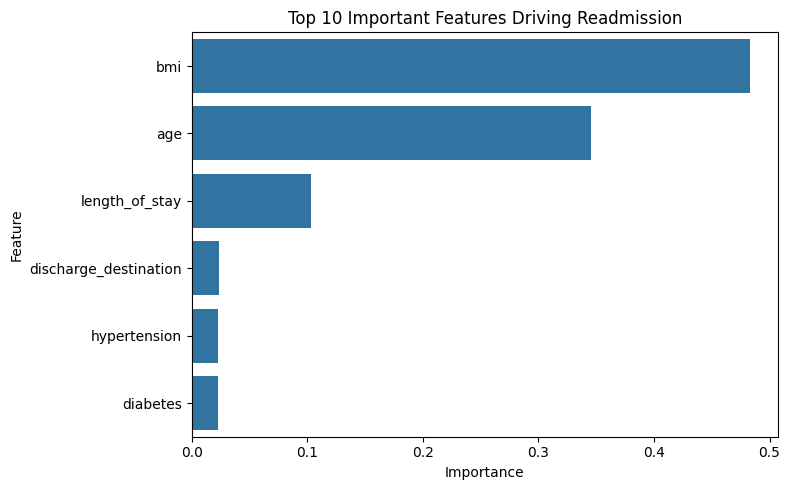

In [52]:
# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importances.head(10))
plt.title('Top 10 Important Features Driving Readmission')
plt.tight_layout()
plt.show()

In [ ]:
# Insights from Feature Importance

# BMI (48%) — Strongest predictor. Indicates that patients with very high or very low BMI are more likely to be readmitted.

# Age (35%) — Older patients have higher risk due to slower recovery and chronic conditions.

# Length of Stay (10%) — Longer hospital stays suggest severe cases → higher readmission likelihood.

# Discharge Destination (2%) — Discharge to nursing facilities correlates with more readmissions than discharge to home.

# Diabetes / Hypertension (~2%) — Chronic comorbidities slightly increase risk.